# Сведение Fandango с другими сайтами

Это ключевой ноутбук для проверки гипотезы. Здесь объединяются данные Fandango и других агрегаторов по одинаковым фильмам, после чего все оценки приводятся к единой шкале 0..5.


In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white', palette='Set2')


## Объединение датасетов

Оставляем только те фильмы, которые встречаются и в `fandango_scrape.csv`, и в `all_sites_scores.csv`. Это важно, иначе сравнение было бы некорректным из-за разных составов выборки.


In [33]:
fdg = pd.read_csv('../data/fandango_scrape.csv')
sites = pd.read_csv('../data/all_sites_scores.csv')

df = pd.merge(fdg, sites, left_on='FILM', right_on='FILM', how='inner')
df.head()


,FILM,STARS,RATING,VOTES,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB,Metacritic_user_vote_count,IMDB_user_vote_count
0,Fifty Shades of Grey (2015),4.0,3.9,34846,25,42,46,3.2,4.2,778,179506
1,Jurassic World (2015),4.5,4.5,34390,71,81,59,7.0,7.3,1281,241807
2,American Sniper (2015),5.0,4.8,34085,72,85,72,6.6,7.4,850,251856
3,Furious 7 (2015),5.0,4.8,33538,81,84,67,6.8,7.4,764,207211
4,Inside Out (2015),4.5,4.5,15749,98,90,94,8.9,8.6,807,96252


## Нормализация шкал

У разных платформ разные диапазоны оценок: где-то 0..100, где-то 0..10, где-то 0..5. Приводим всё к общей шкале 0..5, чтобы сравнение плотностей было честным.


In [34]:
norm_scores = pd.DataFrame()

norm_scores['film'] = df['FILM']
norm_scores['fandango'] = df['STARS']
norm_scores['fandango_user'] = df['RATING']
norm_scores['RottenTomatoes'] = (df['RottenTomatoes'] / 20).round(1)
norm_scores['RottenTomatoes_User'] = (df['RottenTomatoes_User'] / 20).round(1)
norm_scores['Metacritic'] = (df['Metacritic'] / 20).round(1)
norm_scores['Metacritic_User'] = (df['Metacritic_User'] / 2).round(1)
norm_scores['IMDB'] = (df['IMDB'] / 2).round(1)
norm_scores.head()


,film,fandango,fandango_user,RottenTomatoes,RottenTomatoes_User,Metacritic,Metacritic_User,IMDB
0,Fifty Shades of Grey (2015),4.0,3.9,1.2,2.1,2.3,1.6,2.1
1,Jurassic World (2015),4.5,4.5,3.6,4.0,3.0,3.5,3.6
2,American Sniper (2015),5.0,4.8,3.6,4.2,3.6,3.3,3.7
3,Furious 7 (2015),5.0,4.8,4.0,4.2,3.4,3.4,3.7
4,Inside Out (2015),4.5,4.5,4.9,4.5,4.7,4.4,4.3


## Сравнение распределений на общей шкале

Если распределение Fandango заметно смещено вправо относительно других сайтов, это и есть основной визуальный аргумент в пользу гипотезы о завышении.


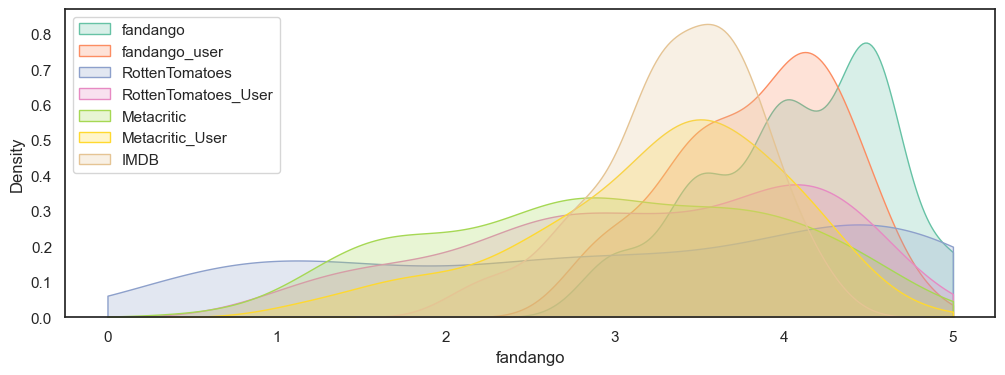

In [35]:
plt.figure(figsize=(12, 4))
sns.kdeplot(norm_scores['fandango'], label='fandango', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['fandango_user'], label='fandango_user', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['RottenTomatoes'], label='RottenTomatoes', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['RottenTomatoes_User'], label='RottenTomatoes_User', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['Metacritic'], label='Metacritic', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['Metacritic_User'], label='Metacritic_User', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores['IMDB'], label='IMDB', clip=(0, 5), fill=True)
plt.legend()


## Самые слабые фильмы по Rotten Tomatoes

Дополнительно смотрим на 10 фильмов с худшими оценками критиков на Rotten Tomatoes. Если даже здесь Fandango остаётся заметно выше остальных площадок, это особенно сильный индикатор систематического смещения вверх.


In [36]:
norm_scores_worst_10_by_rt = norm_scores.nsmallest(10, 'RottenTomatoes')


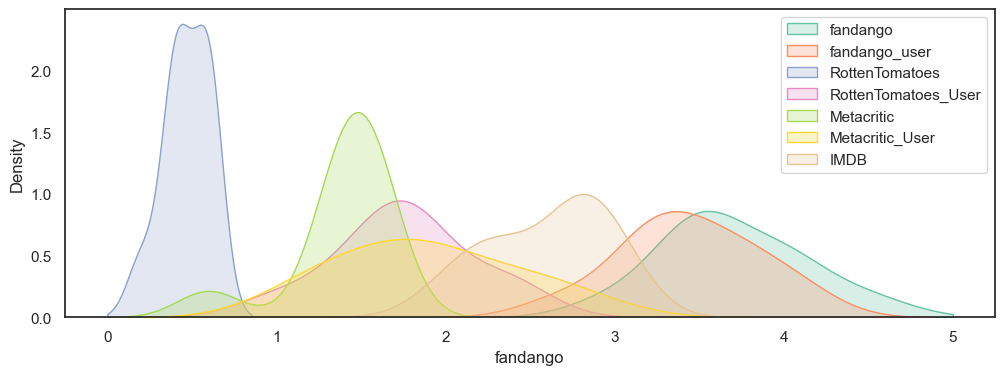

In [37]:
plt.figure(figsize=(12, 4))
sns.kdeplot(norm_scores_worst_10_by_rt['fandango'], label='fandango', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['fandango_user'], label='fandango_user', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['RottenTomatoes'], label='RottenTomatoes', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['RottenTomatoes_User'], label='RottenTomatoes_User', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['Metacritic'], label='Metacritic', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['Metacritic_User'], label='Metacritic_User', clip=(0, 5), fill=True)
sns.kdeplot(norm_scores_worst_10_by_rt['IMDB'], label='IMDB', clip=(0, 5), fill=True)
plt.legend()


## Итоговый вывод

После приведения шкал к единому виду Fandango выглядит более щедрой площадкой, чем Rotten Tomatoes, Metacritic и IMDb. Особенно показательно, что даже для фильмов с очень слабой оценкой критиков Fandango сохраняет сравнительно высокие значения.
